In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn import metrics
import pickle

In [2]:
data=pd.read_csv('out time separated.csv')
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Shape,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
0,0,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,18
1,1,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,11
2,2,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,11
3,3,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,13
4,4,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,11


In [3]:
data=data.sample(frac=1)
#data= data[data['Detector_Size'] == 10]
#data.drop(['Unnamed: 0','Shape','Detector_Size','Cover_Size','CH4','CO2'],axis=1,inplace=True)
#data= data.set_index('Event')


#data= data[data['Gas_Type'] != 'p10']
data.drop(['Shape'],axis=1,inplace=True)


data = data[data['Time_Window'].isin([10, 15, 25])]
#data.drop(['Time_Window'],axis=1,inplace=True)



#data= data[(data['Voltage'] >= 4500) & (data['Voltage'] <= 5500)]
#data= data[data['Detector_Size'] == 10]

#data.drop(['Voltage'],axis=1,inplace=True)


In [4]:
#groupByData = data.groupby(['Gas_Type', 'Detector_Size','Cover_Size','Voltage','Time_Window','Source'])

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7370 entries, 54249 to 3058
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        7370 non-null   int64  
 1   Gas_Type          7370 non-null   object 
 2   CH4               7370 non-null   float64
 3   Ar                7370 non-null   float64
 4   N2                7370 non-null   float64
 5   CO2               7370 non-null   float64
 6   C                 7370 non-null   float64
 7   O                 7370 non-null   float64
 8   H                 7370 non-null   float64
 9   Detector_Size     7370 non-null   float64
 10  Detector_Area     7370 non-null   float64
 11  Cover_Size        7370 non-null   float64
 12  Cover_Area        7370 non-null   float64
 13  Cover_Area_Ratio  7370 non-null   float64
 14  Voltage           7370 non-null   int64  
 15  Source            7370 non-null   object 
 16  Time_Window       7370 non-null   int64  
 

In [6]:
data.isnull()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
54249,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
58506,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
42697,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
452,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
42702,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56374,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1861,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
22392,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
41746,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
data.isnull().sum()

Unnamed: 0          0
Gas_Type            0
CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

<Axes: >

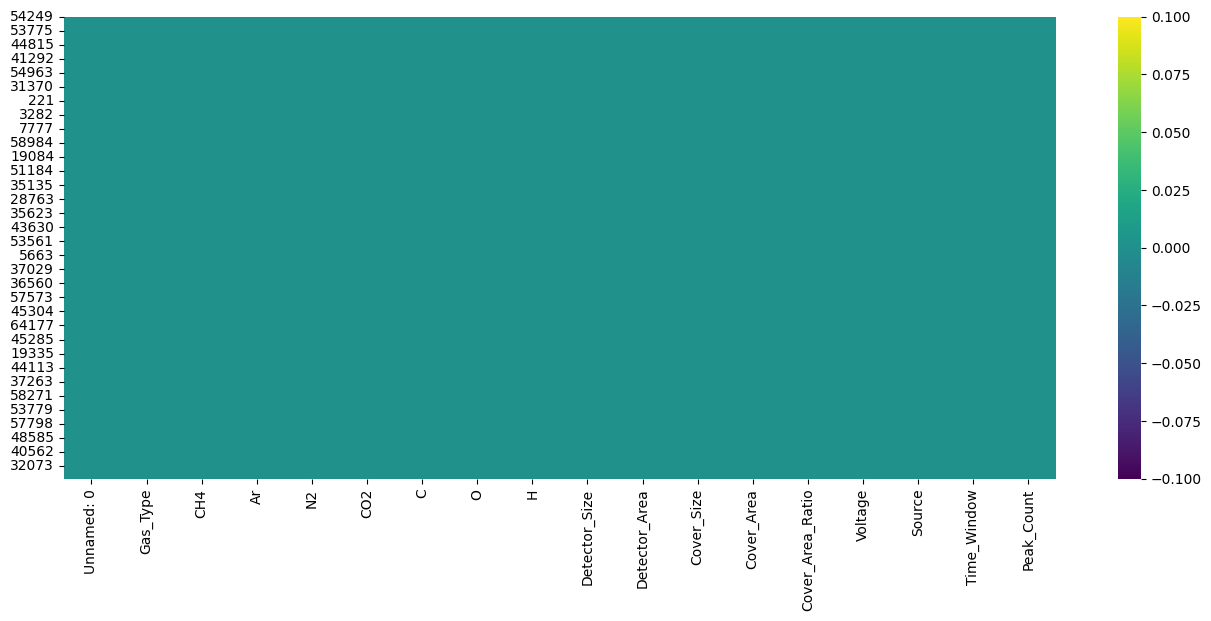

In [8]:
plt.figure(figsize=(16, 6))
sns.heatmap(data.isnull(),cmap='viridis')

In [9]:
data.dropna(inplace=True)

In [10]:
data.isnull().sum()

Unnamed: 0          0
Gas_Type            0
CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

In [11]:
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
54249,54249,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,5500,kaynaksız,10,13
58506,58506,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,6500,kaynaksız,10,558
42697,42697,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,3500,cs,15,0
452,452,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,7500,cs,10,94
42702,42702,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,3500,cs,15,0


In [12]:
type2=pd.get_dummies(data['Gas_Type'],dtype=float)
type2

,arnco2,p10,p20
54249,1.0,0.0,0.0
58506,1.0,0.0,0.0
42697,0.0,0.0,1.0
452,0.0,1.0,0.0
42702,0.0,0.0,1.0
...,...,...,...
56374,1.0,0.0,0.0
1861,0.0,1.0,0.0
22392,0.0,1.0,0.0
41746,0.0,0.0,1.0


In [13]:
type=pd.get_dummies(data['Source'],dtype=float)
type

,cs,kaynaksız
54249,0.0,1.0
58506,0.0,1.0
42697,1.0,0.0
452,1.0,0.0
42702,1.0,0.0
...,...,...
56374,0.0,1.0
1861,0.0,1.0
22392,1.0,0.0
41746,1.0,0.0


In [14]:
data['KV2'] = (data['Voltage']/1000)**2
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count,KV2
54249,54249,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,5500,kaynaksız,10,13,30.25
58506,58506,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,6500,kaynaksız,10,558,42.25
42697,42697,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,3500,cs,15,0,12.25
452,452,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,7500,cs,10,94,56.25
42702,42702,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,3500,cs,15,0,12.25


In [15]:
data=pd.concat([data,type2,type],axis=1)
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,...,Voltage,Source,Time_Window,Peak_Count,KV2,arnco2,p10,p20,cs,kaynaksız
54249,54249,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,...,5500,kaynaksız,10,13,30.25,1.0,0.0,0.0,0.0,1.0
58506,58506,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,...,6500,kaynaksız,10,558,42.25,1.0,0.0,0.0,0.0,1.0
42697,42697,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,...,3500,cs,15,0,12.25,0.0,0.0,1.0,1.0,0.0
452,452,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,...,7500,cs,10,94,56.25,0.0,1.0,0.0,1.0,0.0
42702,42702,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,...,3500,cs,15,0,12.25,0.0,0.0,1.0,1.0,0.0


In [16]:
#sns.set(style="ticks", color_codes=True)
#g = sns.pairplot(data)
#plt.show()

In [17]:
data.drop(['Source','kaynaksız','Gas_Type','Unnamed: 0'],axis=1,inplace=True)
#data.drop(['CH4','Ar','N2','CO2','C','O','H'],axis=1,inplace=True)
data.drop(['p10','p20','arnco2'],axis=1,inplace=True)


data.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,Peak_Count,KV2,cs
54249,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,5500,10,13,30.25,0.0
58506,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,6500,10,558,42.25,0.0
42697,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,3500,15,0,12.25,1.0
452,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,7500,10,94,56.25,1.0
42702,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,3500,15,0,12.25,1.0


In [18]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7370 entries, 54249 to 3058
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CH4               7370 non-null   float64
 1   Ar                7370 non-null   float64
 2   N2                7370 non-null   float64
 3   CO2               7370 non-null   float64
 4   C                 7370 non-null   float64
 5   O                 7370 non-null   float64
 6   H                 7370 non-null   float64
 7   Detector_Size     7370 non-null   float64
 8   Detector_Area     7370 non-null   float64
 9   Cover_Size        7370 non-null   float64
 10  Cover_Area        7370 non-null   float64
 11  Cover_Area_Ratio  7370 non-null   float64
 12  Voltage           7370 non-null   int64  
 13  Time_Window       7370 non-null   int64  
 14  Peak_Count        7370 non-null   int64  
 15  KV2               7370 non-null   float64
 16  cs                7370 non-null   float64
d

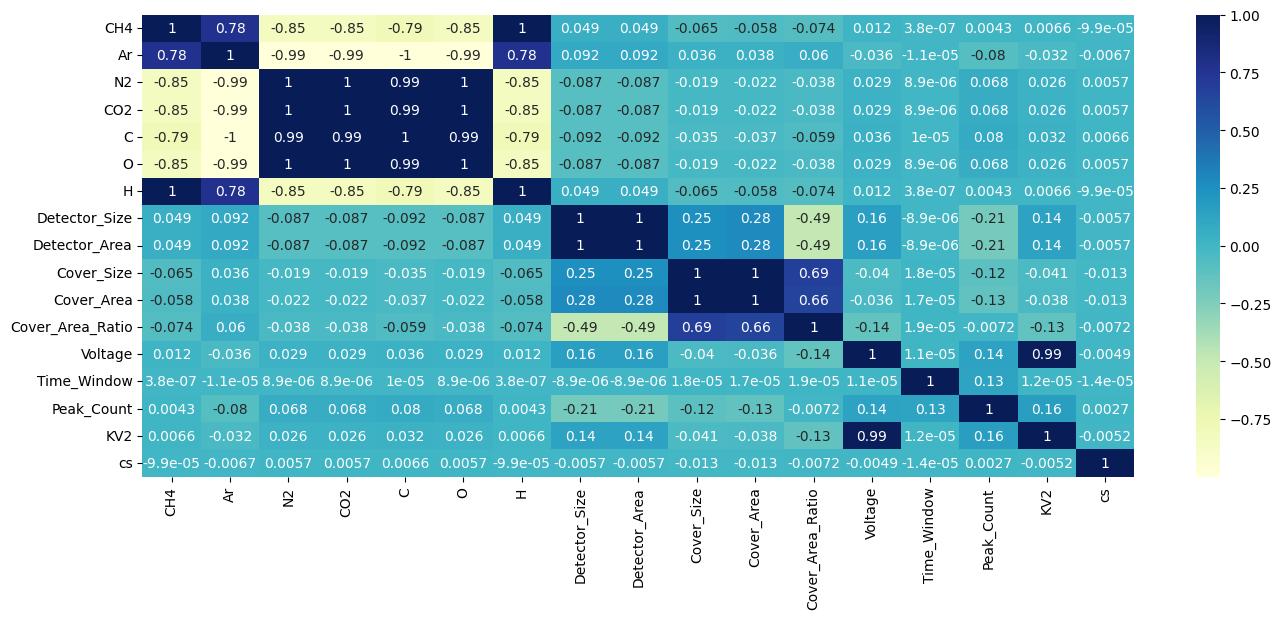

In [19]:
# creation of correlation matrix
corrM = data.corr()
plt.figure(figsize=(16, 6))
dataplot = sns.heatmap(corrM, cmap="YlGnBu", annot=True) 


In [20]:
corr = corrM[abs(corrM['Peak_Count'])>0.1][['Peak_Count']]
list(corr.index)

['Detector_Size',
 'Detector_Area',
 'Cover_Size',
 'Cover_Area',
 'Voltage',
 'Time_Window',
 'Peak_Count',
 'KV2']

In [21]:
#data=data[list(corr.index)]
data

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,Peak_Count,KV2,cs
54249,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,5500,10,13,30.25,0.0
58506,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,6500,10,558,42.25,0.0
42697,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,3500,15,0,12.25,1.0
452,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,7500,10,94,56.25,1.0
42702,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,3500,15,0,12.25,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56374,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,5000,10,8,25.00,0.0
1861,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,5000,10,75,25.00,0.0
22392,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,2000,10,0,4.00,1.0
41746,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,4500,10,3,20.25,1.0


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
x=data.drop(['Peak_Count'],axis=1)

x.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,KV2,cs
54249,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,5500,10,30.25,0.0
58506,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,6500,10,42.25,0.0
42697,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,3500,15,12.25,1.0
452,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,7500,10,56.25,1.0
42702,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,3500,15,12.25,1.0


In [24]:
y=data['Peak_Count']
y

54249     13
58506    558
42697      0
452       94
42702      0
        ... 
56374      8
1861      75
22392      0
41746      3
3058      26
Name: Peak_Count, Length: 7370, dtype: int64

In [25]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
model=LinearRegression()

In [28]:
model.fit(X_train,y_train)

LinearRegression()

In [29]:
pred=model.predict(X_test)
pred

array([ 309.84642711,  777.60428798, 1090.89654524, ...,  422.34100315,
        350.67479483,   -6.89324215])

In [30]:
y_test

57082      56
62756     475
44807    1415
37968     116
17199     176
         ... 
63940    1103
8259       23
55437     102
49079       0
37977     153
Name: Peak_Count, Length: 1474, dtype: int64

In [31]:
X_test

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,KV2,cs
57082,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,7500,10,56.25,1.0
62756,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,5500,15,30.25,1.0
44807,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,7500,10,56.25,1.0
37968,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,5000,10,25.00,0.0
17199,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,8.00,64.00,0.64,4500,10,20.25,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63940,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,7500,15,56.25,1.0
8259,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,4.00,16.00,0.16,3000,25,9.00,0.0
55437,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,8000,10,64.00,0.0
49079,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,5500,25,30.25,1.0


In [32]:
model.score(X_test, y_test)

0.10773530583818314

In [33]:
pred

array([ 309.84642711,  777.60428798, 1090.89654524, ...,  422.34100315,
        350.67479483,   -6.89324215])

In [34]:
y_test

57082      56
62756     475
44807    1415
37968     116
17199     176
         ... 
63940    1103
8259       23
55437     102
49079       0
37977     153
Name: Peak_Count, Length: 1474, dtype: int64

In [35]:
indexes = X_test.index.values
#index=indexes[98]

In [36]:
#X_test.loc[index]

In [37]:
#y_test[index],pred[98]
pred[pred<=0] = 0

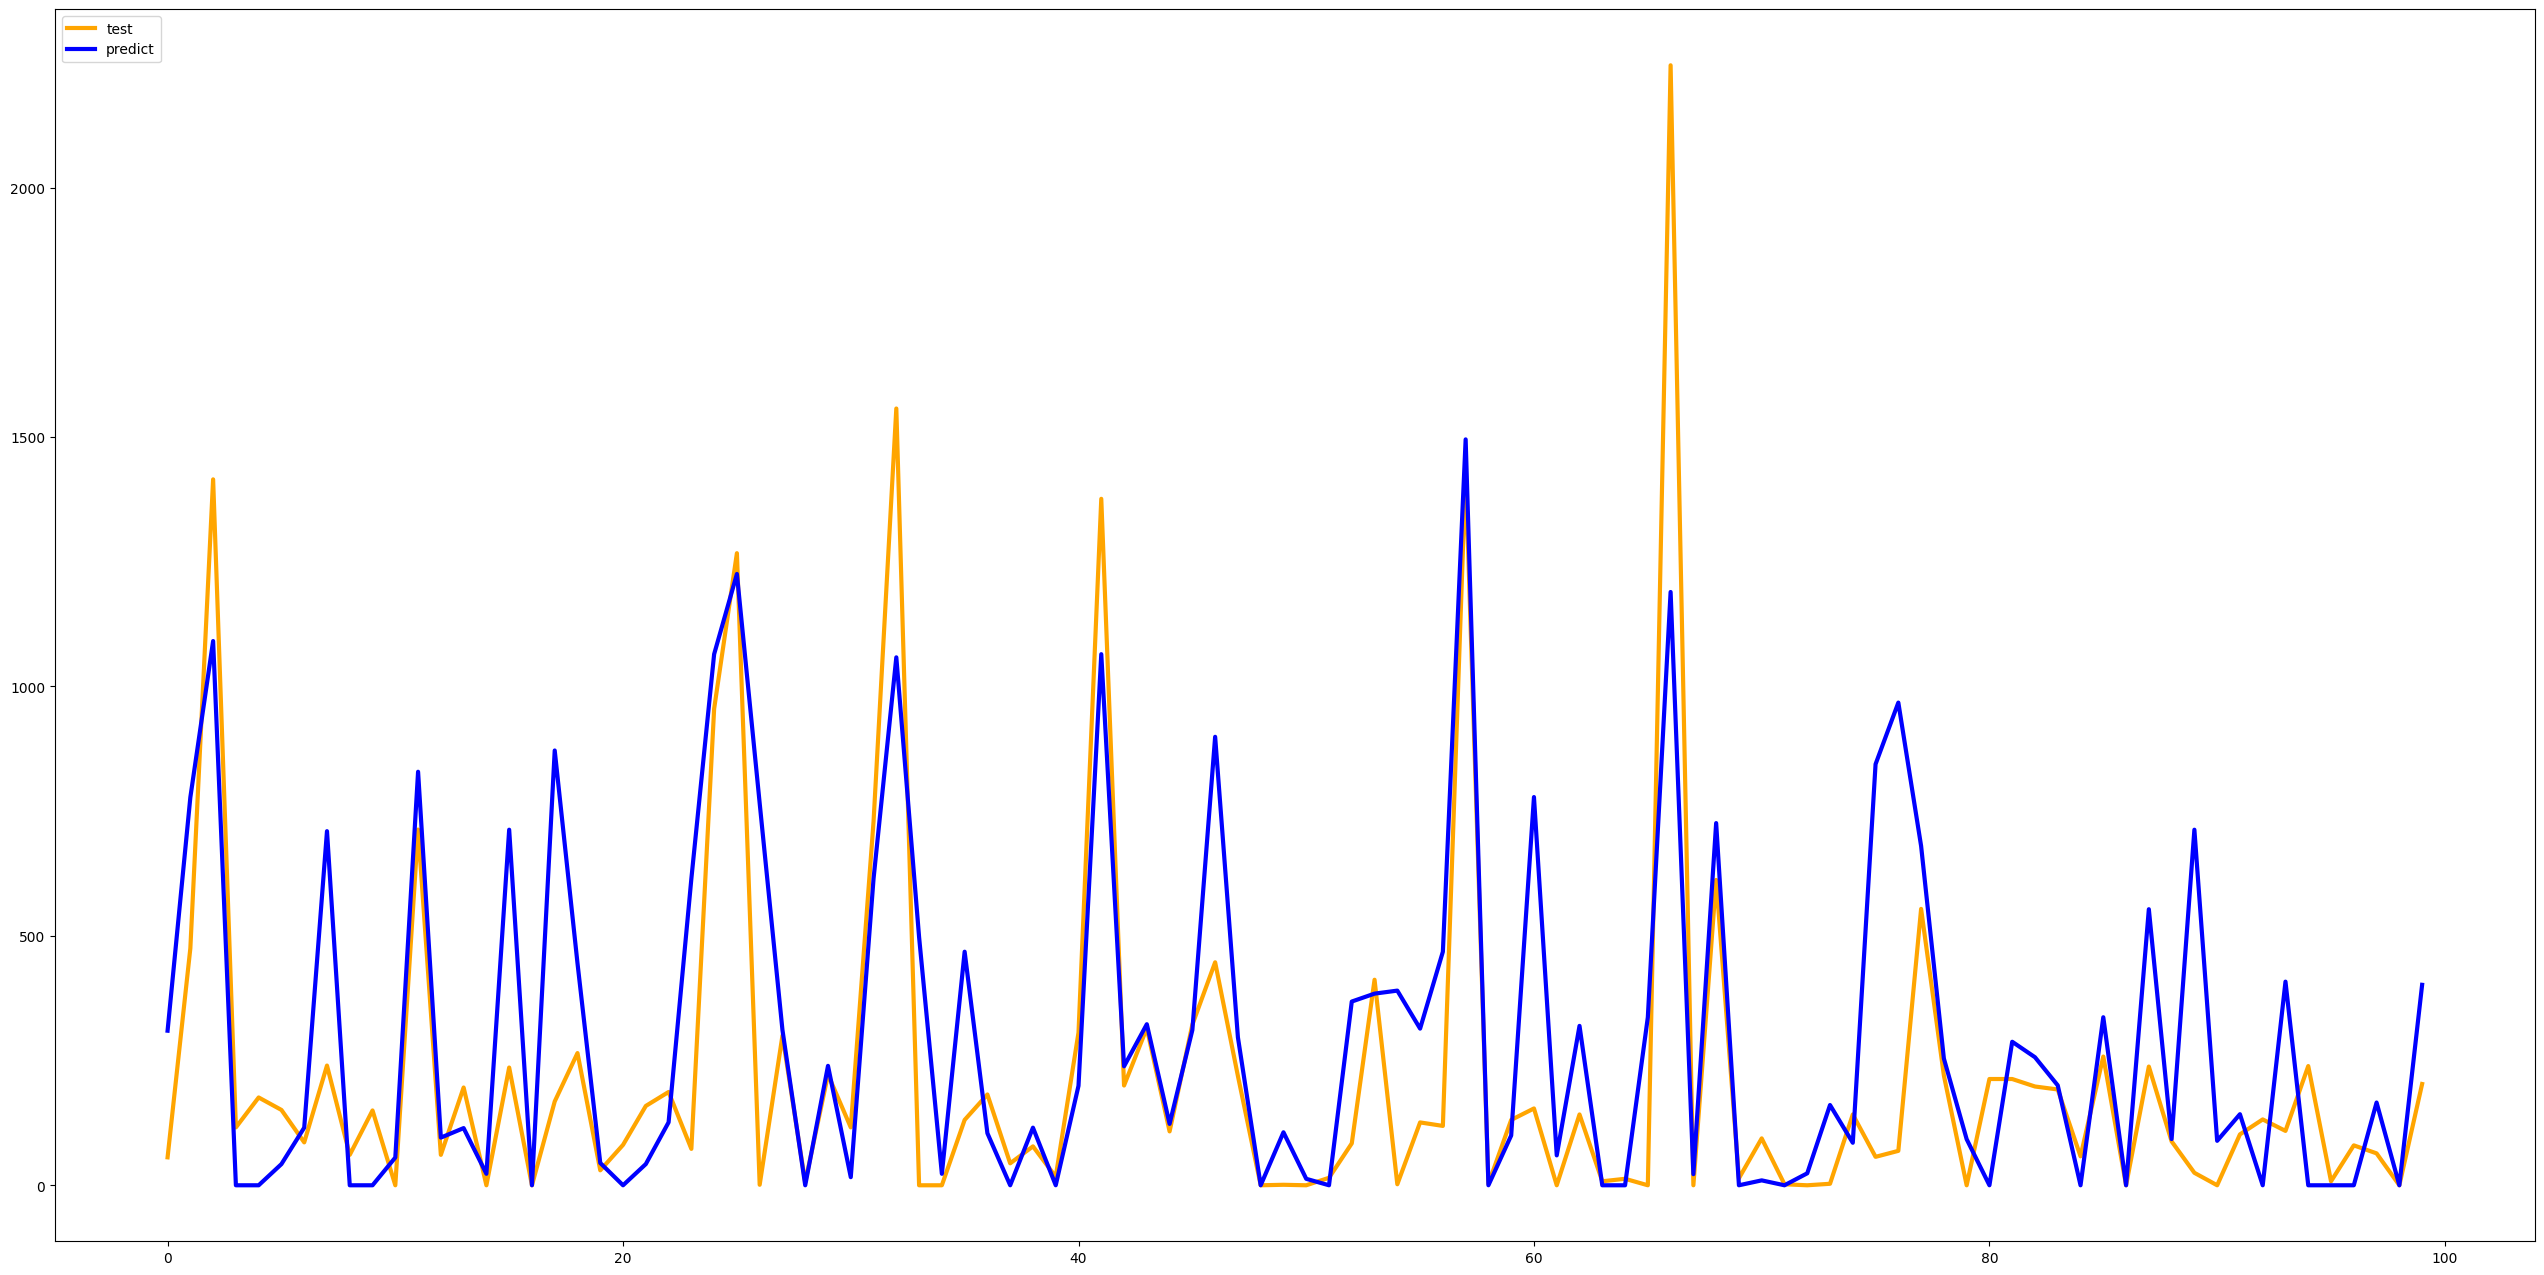

In [38]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(indexes))[:100],y_test[:100], color="orange", linewidth=3 ,label = 'test')
plt.plot(range(0,len(indexes))[:100],pred[:100], color="blue", linewidth=3,label = 'predict')
plt.legend(loc="upper left")
plt.show()

In [39]:
indexes = X_test.index.values
#index=indexes[98]

In [40]:
#X_test.loc[index]

In [41]:
#y_test[index],pred[98]

In [42]:
#metrics.mean_absolute_error(y_true, y_pred, *) -> Mean absolute error regression loss.
metrics.mean_absolute_error(y_test, pred)

346.0045333520026

In [43]:
#metrics.mean_squared_error(y_true, y_pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred)

1412460.708683253

In [44]:
#metrics.mean_squared_error(y_true, pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred)**0.5

1188.4699023043256

In [45]:
#metrics.mean_absolute_percentage_error(...) -> Mean absolute percentage error (MAPE) regression loss.
metrics.mean_absolute_percentage_error(y_test, pred)

1.6062700962051117e+17

In [46]:
#metrics.r2_score(y_true, y_pred, *[, ...]) -> (coefficient of determination) regression score function.
metrics.r2_score(y_test, pred)

0.11050042423757145

In [47]:
metrics.explained_variance_score(y_test, pred)

0.1111405262966606

In [48]:
from pyGRNN import GRNN

In [49]:
model_grnn = GRNN(sigma=5)

In [50]:
#dbfile = open('grnn_model.pickle', 'ab')
#pickle.dump(model_grnn, dbfile)                    
#dbfile.close()

In [51]:
with (open("grnn_model.pickle", "rb")) as openfile:
    model_grnn=pickle.load(openfile)

#model_grnn.fit(X_train,y_train)

In [52]:
pred_grnn=model_grnn.predict(X_test)
pred_grnn

array([7.20849080e+01, 3.35806167e+02, 1.39825848e+03, ...,
       1.09279788e+02, 1.81254188e-04, 1.63210283e+02])

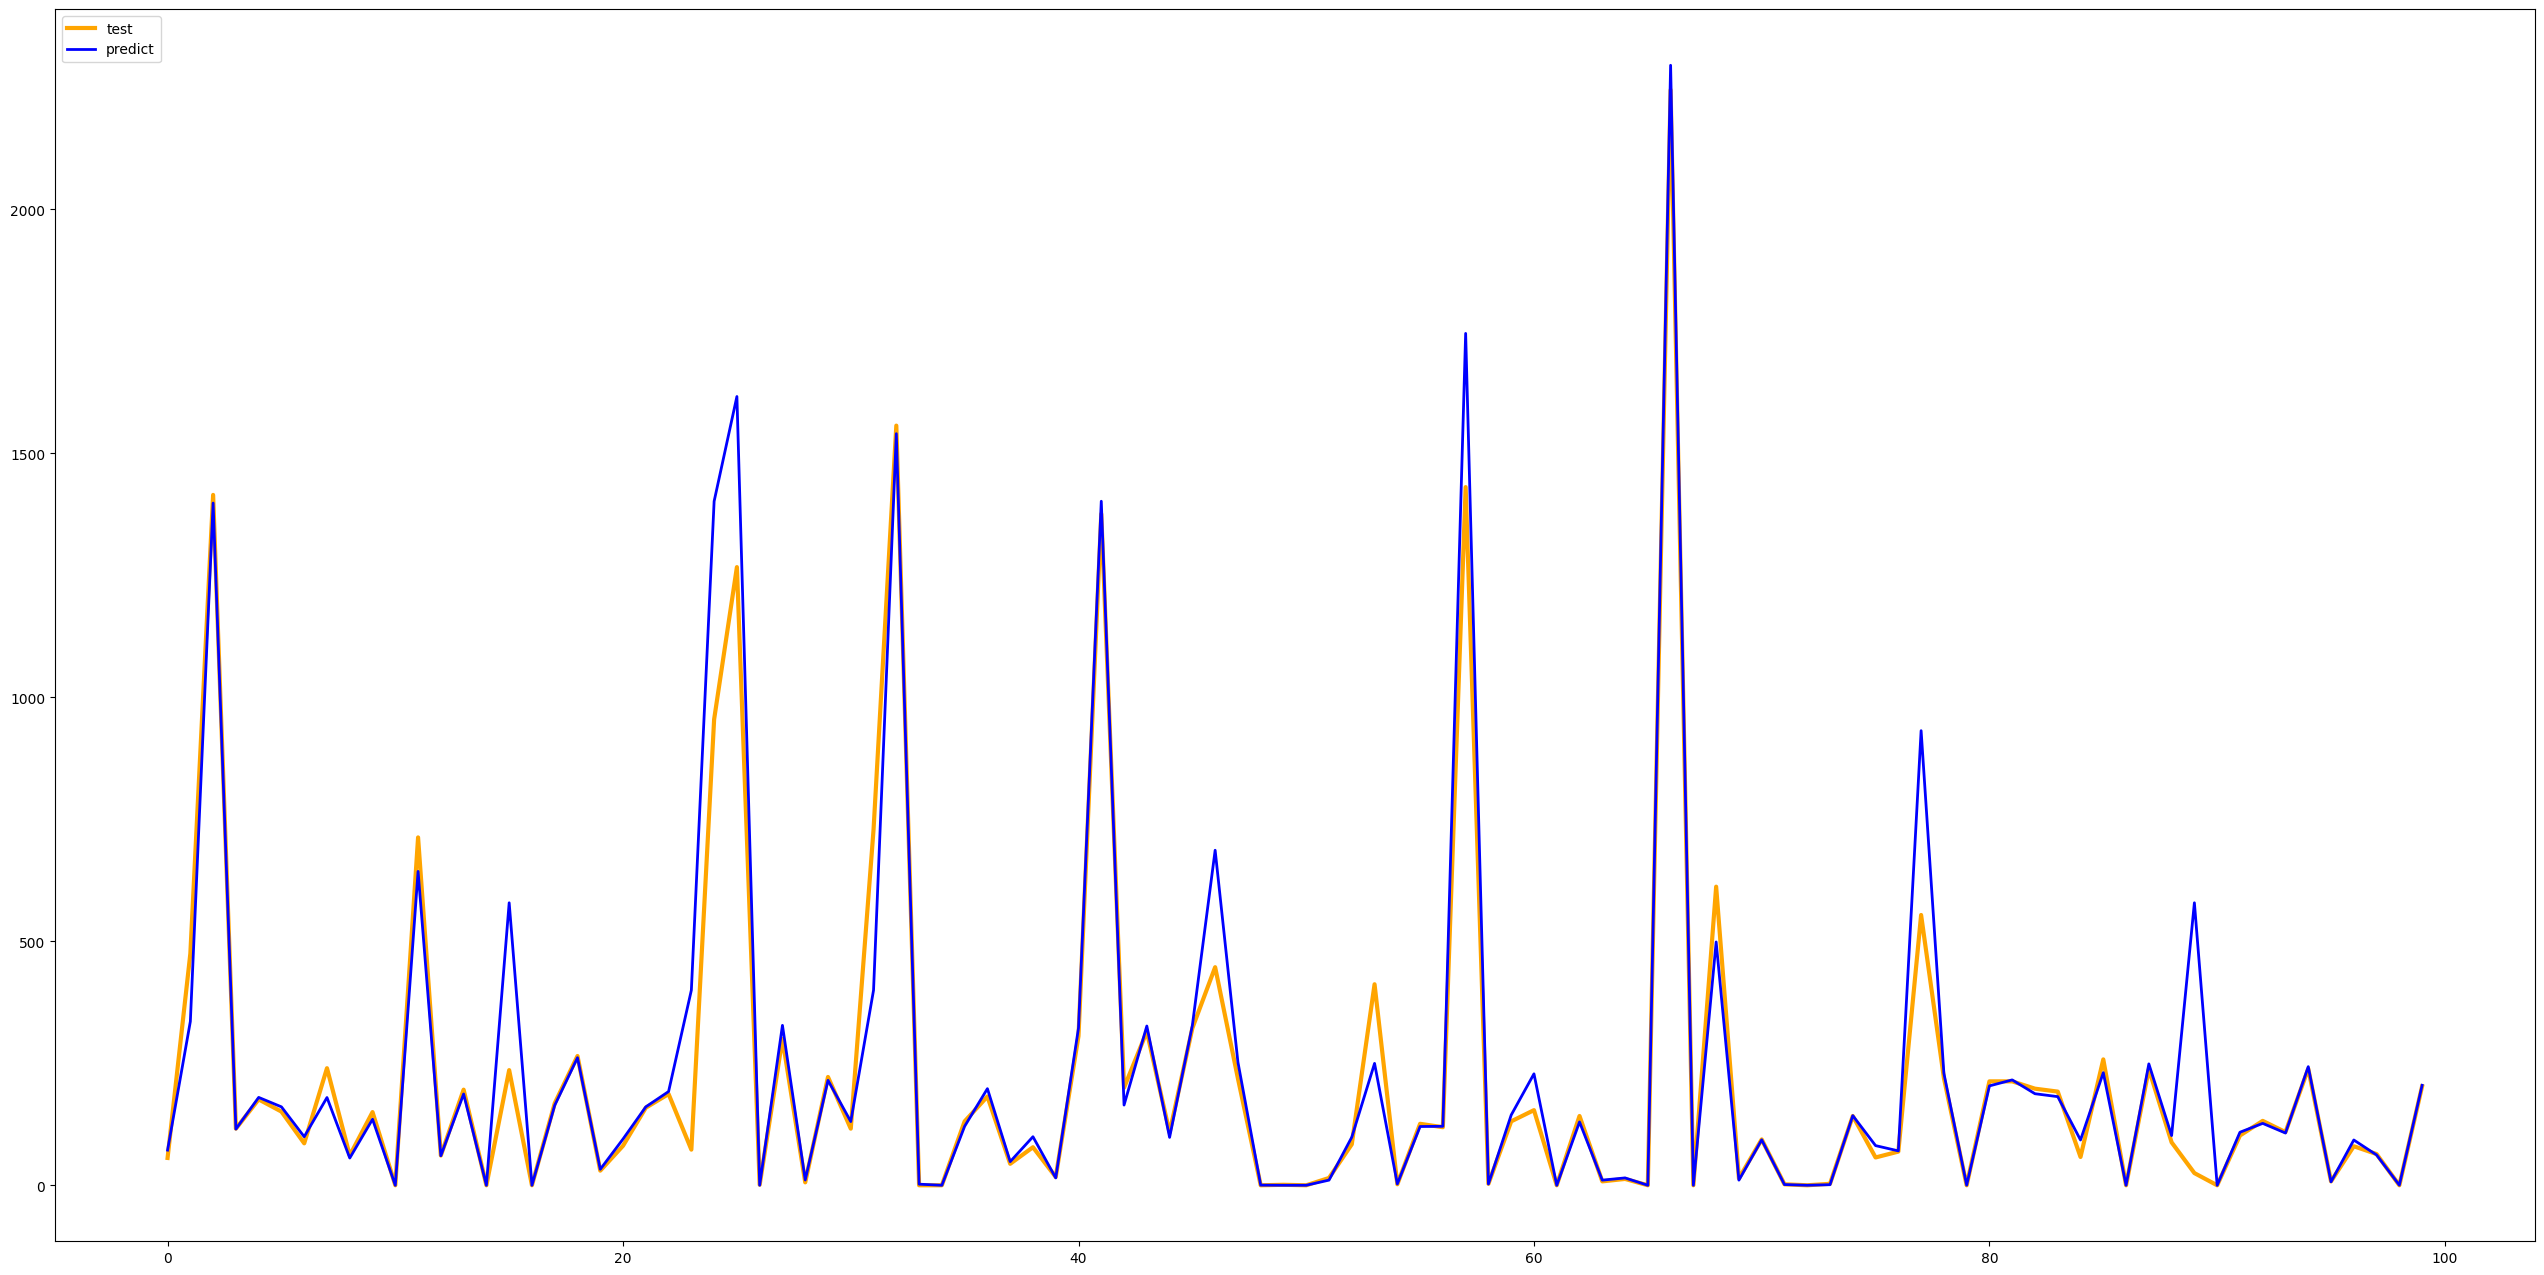

In [53]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(indexes))[:100],y_test[:100], color="orange", linewidth=3 ,label = 'test')
plt.plot(range(0,len(indexes))[:100],pred_grnn[:100], color="blue", linewidth=2,label = 'predict')
plt.legend(loc="upper left")
plt.show()

In [54]:
X_test['olcum'] = y_test
X_test['tahmin'] = pred_grnn
X_test

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,KV2,cs,olcum,tahmin
57082,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,7500,10,56.25,1.0,56,72.084908
62756,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,5500,15,30.25,1.0,475,335.806167
44807,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,7500,10,56.25,1.0,1415,1398.258483
37968,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,5000,10,25.00,0.0,116,115.208482
17199,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,8.00,64.00,0.64,4500,10,20.25,1.0,176,180.112340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63940,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,7500,15,56.25,1.0,1103,1046.401676
8259,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,4.00,16.00,0.16,3000,25,9.00,0.0,23,22.445862
55437,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,8000,10,64.00,0.0,102,109.279788
49079,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,5500,25,30.25,1.0,0,0.000181


In [55]:
#metrics.mean_absolute_error(y_true, y_pred, *) -> Mean absolute error regression loss.
metrics.mean_absolute_error(y_test, pred_grnn)

75.49053358983667

In [56]:
#metrics.mean_squared_error(y_true, y_pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred_grnn)

123790.00506569885

In [57]:
#metrics.mean_squared_error(y_true, pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred_grnn)**0.5

351.8380381165442

In [58]:
#metrics.mean_absolute_percentage_error(...) -> Mean absolute percentage error (MAPE) regression loss.
metrics.mean_absolute_percentage_error(y_test, pred_grnn)

150610707736758.6

In [59]:
#metrics.r2_score(y_true, y_pred, *[, ...]) -> (coefficient of determination) regression score function.
metrics.r2_score(y_test, pred_grnn)

0.9220430300732276

In [60]:
metrics.explained_variance_score(y_test, pred_grnn)

0.9220437820209542

In [61]:
row = data.loc[data.index.values[0]]
row

CH4                    0.00
Ar                     0.05
N2                     0.35
CO2                    0.60
C                      0.20
O                      0.40
H                      0.00
Detector_Size         10.00
Detector_Area        100.00
Cover_Size             8.00
Cover_Area            64.00
Cover_Area_Ratio       0.64
Voltage             5500.00
Time_Window           10.00
Peak_Count            13.00
KV2                   30.25
cs                     0.00
Name: 54249, dtype: float64

In [62]:
row = dict(row)
row

{'CH4': 0.0,
 'Ar': 0.05,
 'N2': 0.35,
 'CO2': 0.6,
 'C': 0.2,
 'O': 0.4,
 'H': 0.0,
 'Detector_Size': 10.0,
 'Detector_Area': 100.0,
 'Cover_Size': 8.0,
 'Cover_Area': 64.0,
 'Cover_Area_Ratio': 0.64,
 'Voltage': 5500.0,
 'Time_Window': 10.0,
 'Peak_Count': 13.0,
 'KV2': 30.25,
 'cs': 0.0}

In [63]:
row = {'CH4': 0.3,
 'Ar': 0.7,
 'N2': 0.0,
 'CO2': 0.0,
 'C': 0.06,
 'O': 0.0,
 'H': 0.24,
 'Detector_Size': 10.0,
 'Detector_Area': 100.0,
 'Cover_Size': 8.0,
 'Cover_Area': 64.0,
 'Cover_Area_Ratio': 0.64,
 'Voltage': 7000.0,
 'Time_Window': 15.0,
 'KV2': 12.25,
 'cs': 1.0}
df = pd.DataFrame.from_dict(row,orient='index').T
df

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,KV2,cs
0,0.3,0.7,0.0,0.0,0.06,0.0,0.24,10.0,100.0,8.0,64.0,0.64,7000.0,15.0,12.25,1.0


In [64]:
model_grnn.predict(df)

array([129.78362268])